# Scaling the exact filler-token probe

This experiment evaluates every combination of
`N ∈ {12,16,20,24,28,32,64,128}` and
`r ∈ {0.0,0.1,...,1.0}`, with 32 deterministic replicates per cell.
It freezes the development-selected underscore token at F=11 and
continues to score exactly one answer token with thinking disabled.

Multi-digit candidate strings are not single Qwen tokens, so each
prompt assigns the two candidates to the single-token aliases `X` and
`Y`. Within every cell, low/high presentation order and the X/Y alias
mapping are each exactly balanced 16/16.


In [1]:
from __future__ import annotations

import json
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook inside the MATS repository.")


def load_jsonl(path: Path) -> list[dict[str, object]]:
    return [json.loads(line) for line in path.read_text().splitlines() if line.strip()]


REPO_ROOT = find_repo_root()
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "filler_token_probe"
plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
results_path = ARTIFACT_DIR / "scaled_grid_results.jsonl"
manifest_path = ARTIFACT_DIR / "scaled_grid_manifest.json"
rows = load_jsonl(results_path)
manifest = json.loads(manifest_path.read_text())

ns = [12, 16, 20, 24, 28, 32, 64, 128]
reliabilities = [round(i / 10, 1) for i in range(11)]
assert manifest["grid"]["n_values"] == ns
assert manifest["grid"]["reliabilities"] == reliabilities
assert len(rows) == 88 * 32 == 2_816
assert manifest["protocol"]["enable_thinking"] is False
assert manifest["protocol"]["generated_reasoning_tokens"] == 0
assert manifest["protocol"]["filler"] == "underscore"
assert manifest["protocol"]["filler_token_id"] == 62
assert manifest["protocol"]["filler_count"] == 11
assert all(row["enable_thinking"] is False for row in rows)

cells = defaultdict(list)
for row in rows:
    cells[(row["n"], row["reliability"])].append(row)
assert len(cells) == 88 and {len(group) for group in cells.values()} == {32}
for group in cells.values():
    assert {row["normative_role"] for row in group} <= {"first", "second", "tie"}
    assert sum(row["first_candidate"] < row["second_candidate"] for row in group) == 16
    assert sum(row["first_alias"] == "X" for row in group) == 16

print("Full 88-cell grid and within-cell counterbalancing: PASS")
print("rows:", len(rows), "single-token answers:", manifest["protocol"]["answer_token_ids"])


Full 88-cell grid and within-cell counterbalancing: PASS
rows: 2816 single-token answers: {'X': 55, 'Y': 56, '=': 28}


## Accuracy across N and reliability


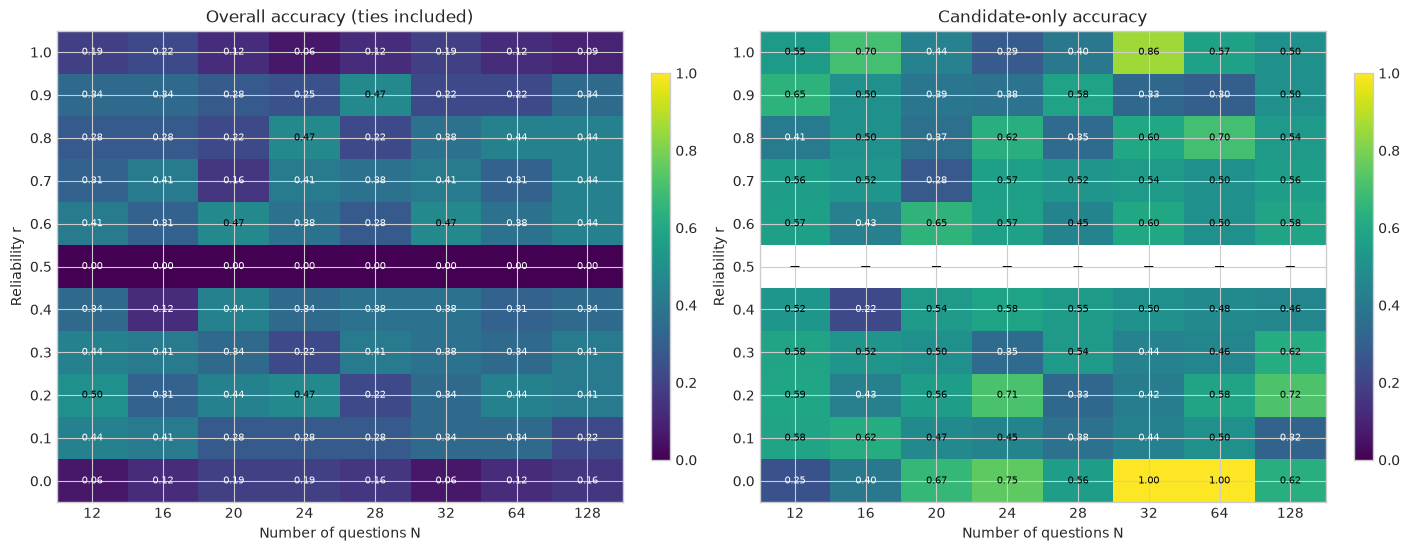

In [3]:
overall = np.empty((len(reliabilities), len(ns)))
candidate = np.empty_like(overall)
for i, reliability in enumerate(reliabilities):
    for j, n in enumerate(ns):
        group = cells[(n, reliability)]
        overall[i, j] = np.mean([row["correct"] for row in group])
        non_ties = [row for row in group if row["normative_answer"] != "tie"]
        candidate[i, j] = (
            np.mean([row["correct"] for row in non_ties]) if non_ties else np.nan
        )

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), constrained_layout=True)
for ax, matrix, title in (
    (axes[0], overall, "Overall accuracy (ties included)"),
    (axes[1], candidate, "Candidate-only accuracy"),
):
    image = ax.imshow(matrix, aspect="auto", origin="lower", vmin=0, vmax=1,
                      cmap="viridis")
    ax.set_xticks(range(len(ns)), ns)
    ax.set_yticks(range(len(reliabilities)), reliabilities)
    ax.set(xlabel="Number of questions N", ylabel="Reliability r", title=title)
    for i in range(len(reliabilities)):
        for j in range(len(ns)):
            value = matrix[i, j]
            label = "—" if np.isnan(value) else f"{value:.2f}"
            color = "white" if not np.isnan(value) and value < 0.45 else "black"
            ax.text(j, i, label, ha="center", va="center", fontsize=7, color=color)
    fig.colorbar(image, ax=ax, shrink=0.82)
figure_path = ARTIFACT_DIR / "exp2_n_reliability_heatmaps.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()


## Presentation-order controls and answer collapse


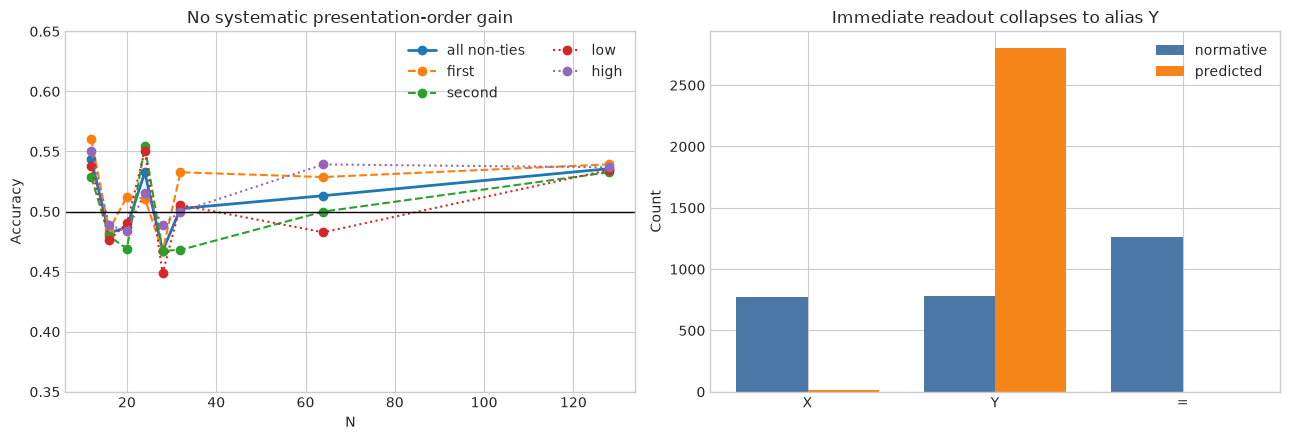

overall accuracy: 0.280
candidate-only accuracy: 0.508
target counts: {'X': 771, '=': 1264, 'Y': 781}
prediction counts: {'Y': 2799, 'X': 17}
recall(X) = 0.010
recall(Y) = 0.999
recall(=) = 0.000


In [4]:
role_rates = {"first": [], "second": [], "low": [], "high": []}
candidate_by_n = []
for n in ns:
    group = [row for row in rows if row["n"] == n and row["normative_role"] != "tie"]
    candidate_by_n.append(np.mean([row["correct"] for row in group]))
    for role in ("first", "second"):
        subset = [row for row in group if row["normative_role"] == role]
        role_rates[role].append(np.mean([row["correct"] for row in subset]))
    for magnitude in ("low", "high"):
        subset = [
            row for row in group
            if (
                row["normative_answer"] == min(row["candidates"])
                if magnitude == "low"
                else row["normative_answer"] == max(row["candidates"])
            )
        ]
        role_rates[magnitude].append(np.mean([row["correct"] for row in subset]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(ns, candidate_by_n, marker="o", linewidth=2, label="all non-ties")
for role, style in (("first", "--"), ("second", "--"), ("low", ":"), ("high", ":")):
    axes[0].plot(ns, role_rates[role], marker="o", linestyle=style, label=role)
axes[0].axhline(0.5, color="black", linewidth=1)
axes[0].set(xlabel="N", ylabel="Accuracy", title="No systematic presentation-order gain",
            ylim=(0.35, 0.65))
axes[0].legend(ncol=2)

prediction_counts = Counter(row["predicted_surface"] for row in rows)
target_counts = Counter(row["normative_surface"] for row in rows)
labels = ["X", "Y", "="]
x = np.arange(len(labels))
width = 0.38
axes[1].bar(x - width / 2, [target_counts[k] for k in labels], width,
            label="normative", color="#4c78a8")
axes[1].bar(x + width / 2, [prediction_counts[k] for k in labels], width,
            label="predicted", color="#f58518")
axes[1].set_xticks(x, labels)
axes[1].set(ylabel="Count", title="Immediate readout collapses to alias Y")
axes[1].legend()
fig.tight_layout()
figure_path = ARTIFACT_DIR / "exp2_position_and_surface_bias.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

non_ties = [row for row in rows if row["normative_answer"] != "tie"]
print("overall accuracy:", f"{np.mean([row['correct'] for row in rows]):.3f}")
print("candidate-only accuracy:", f"{np.mean([row['correct'] for row in non_ties]):.3f}")
print("target counts:", dict(target_counts))
print("prediction counts:", dict(prediction_counts))
for surface in labels:
    subset = [row for row in rows if row["normative_surface"] == surface]
    print(f"recall({surface}) = {np.mean([row['correct'] for row in subset]):.3f}")


## Prompt-length scaling


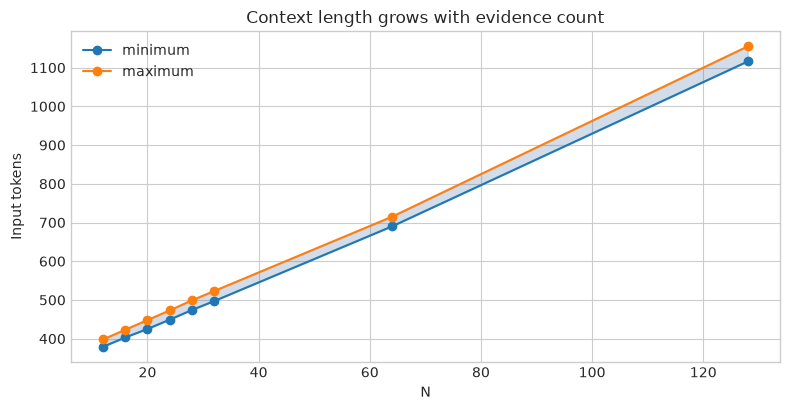

In [5]:
length_min = []
length_max = []
for n in ns:
    lengths = [row["input_token_count"] for row in rows if row["n"] == n]
    length_min.append(min(lengths))
    length_max.append(max(lengths))
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.fill_between(ns, length_min, length_max, alpha=0.25, color="#4c78a8")
ax.plot(ns, length_min, marker="o", label="minimum")
ax.plot(ns, length_max, marker="o", label="maximum")
ax.set(xlabel="N", ylabel="Input tokens", title="Context length grows with evidence count")
ax.legend()
fig.tight_layout()
figure_path = ARTIFACT_DIR / "exp2_prompt_lengths.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()


## Interpretation

Candidate-only accuracy stays near chance at every N (0.467–0.544
after averaging over reliability), while overall accuracy is only
0.280 because the model never emits the tie token. Crucially, this
should not be read as stable candidate reasoning: 2,799 of 2,816
predictions are the surface alias `Y`; recall is 0.010 for X, 0.999
for Y, and 0 for tie.

The exact counterbalance makes presentation position diagnosable.
First/second and low/high candidate accuracies remain close within N,
so ordinary positional bias is not the main failure. The dominant
failure is the single-token answer interface itself—a hypothesis the
alias-swap intervention tests in notebook 08.
